# 1) Imports and Setup

In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch
import scipy.cluster.hierarchy as sch
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from adjustText import adjust_text

# Get the absolute path to the project root
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
models_path = os.path.join(project_root, 'models')
sys.path.append(models_path)

from DKT.dkt_model import DKT

# 2) Model and Data Imports


In [3]:
# Load the JSON file
with open('dkt_best_config.json', 'r') as f:
    best_config = json.load(f)
skills_file_path = os.path.join(os.getcwd(), '..', '..', 'data', 'preprocessed', 'df_skill_names.csv')
df_skill_names = pd.read_csv(skills_file_path)

num_skills = best_config['model_params']['num_skills']
embedding_dim = best_config['model_params']['embed_dim']


model = DKT(**best_config['model_params'])
model.load_state_dict(torch.load('dkt_full_model.pth', map_location=torch.device('cpu')))
# Set the model to evaluation model
model.eval()


C:\Users\Botond\AppData\Local\Temp\ipykernel_20744\4108343498.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dkt_full_model.pth', map

DKT(
  (embedding): CustomEmbedding(
    (linear): Linear(in_features=109, out_features=3, bias=False)
  )
  (rnn): LSTM(8, 200, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=200, out_features=109, bias=True)
  (sigmoid): Sigmoid()
)

In [6]:
embedding_list = []

# Loop over all skill IDs to generate embeddings
for skill_id in range(num_skills):
    embedding = model.get_embedding(skill_id)
    embedding_list.append(embedding)

df_embeddings = pd.DataFrame(embedding_list, columns=[f"embedding_{i+1}" for i in range(embedding_dim)], index=[f"skill_{i+1}" for i in range(num_skills)])
df_embeddings['skill_name'] = df_skill_names['skill_name'].values

df_embeddings = df_embeddings[df_embeddings['skill_name'].notna()]
print(df_embeddings)

           embedding_1  embedding_2  embedding_3  \
skill_1       0.826391     0.577524     0.347534   
skill_2       0.222455     0.589636    -0.160300   
skill_3       0.342879     0.310721     0.270748   
skill_4       0.190475     0.462657     0.026876   
skill_5      -0.871799    -0.199031    -0.194817   
...                ...          ...          ...   
skill_104     0.254793     0.088505     0.056474   
skill_105     0.076357    -0.435419     0.076719   
skill_107     0.083322     0.016111     0.088974   
skill_108     0.297621     0.364791    -0.006892   
skill_109     0.260661     0.331705     0.291777   

                                                skill_name  
skill_1                                    Box and Whisker  
skill_2                                       Circle Graph  
skill_3                        Histogram as Table or Graph  
skill_4                                        Number Line  
skill_5                                       Scatter Plot  
...      

# 3) Visualizations

## 3.1) 3D Visualization


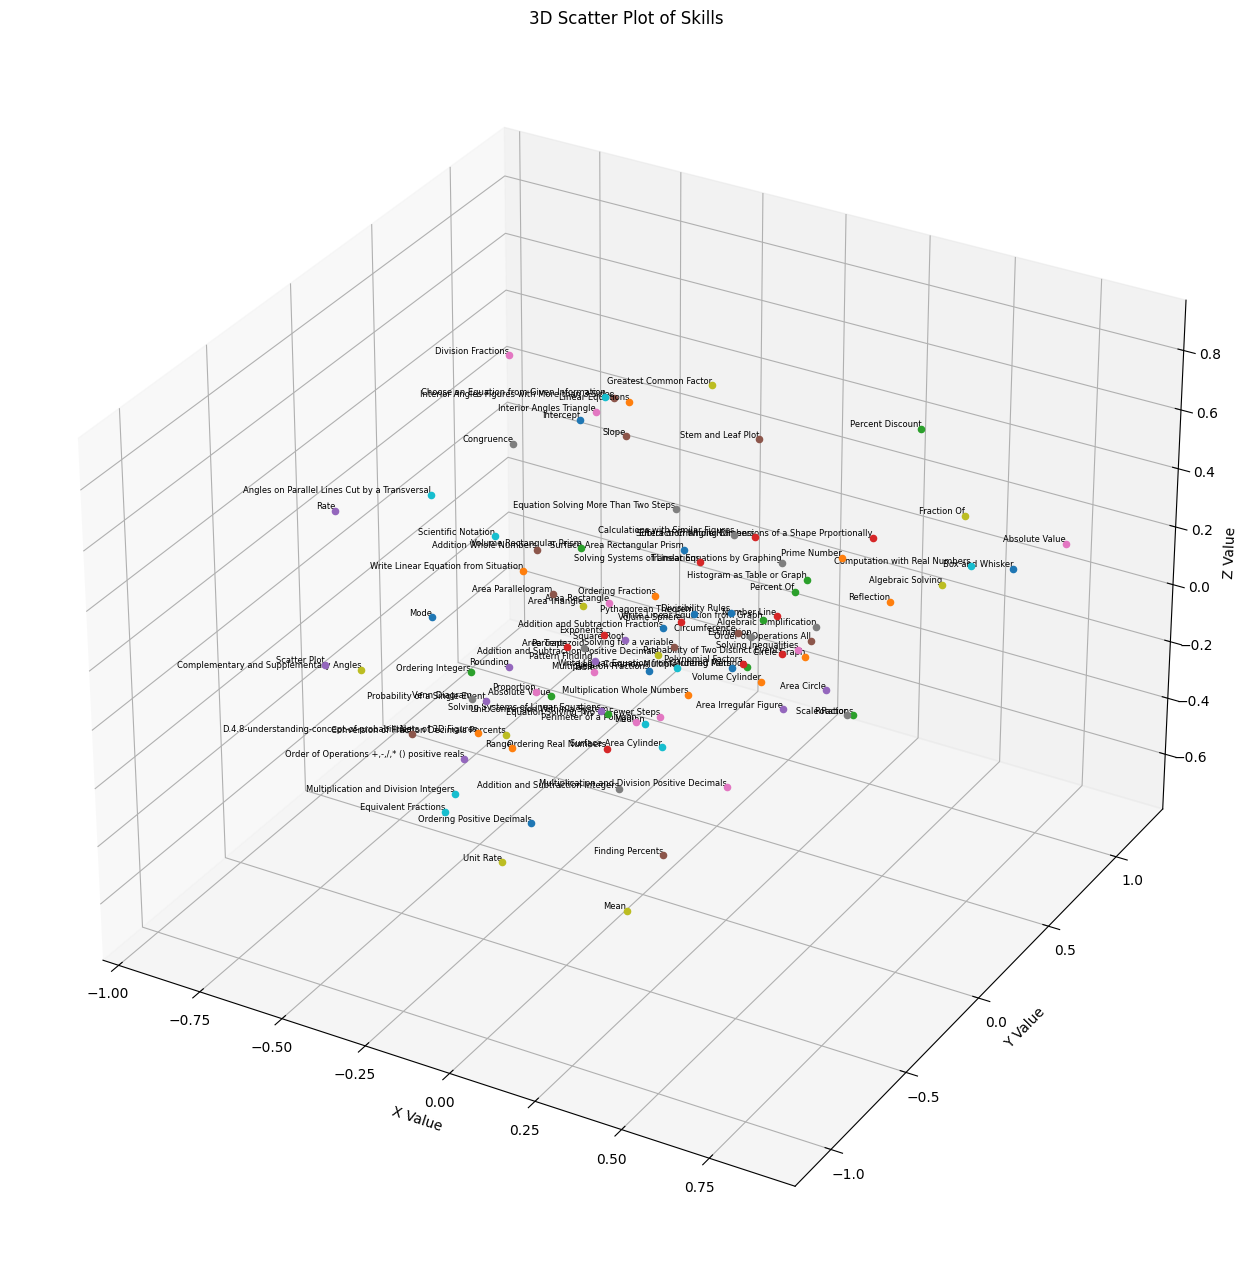

In [5]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
for i, row in df_embeddings.iterrows():
    ax.scatter(row['embedding_1'], row['embedding_2'], row['embedding_3'])  # 3D coordinates
    ax.text(row['embedding_1'], row['embedding_2'], row['embedding_3'], row['skill_name'], fontsize=6, ha='right', va='bottom')

ax.set_xlabel('X Value')
ax.set_ylabel('Y Value')
ax.set_zlabel('Z Value')
ax.set_title('3D Scatter Plot of Skills')

plt.show()


## 3.2) 2D Visualization

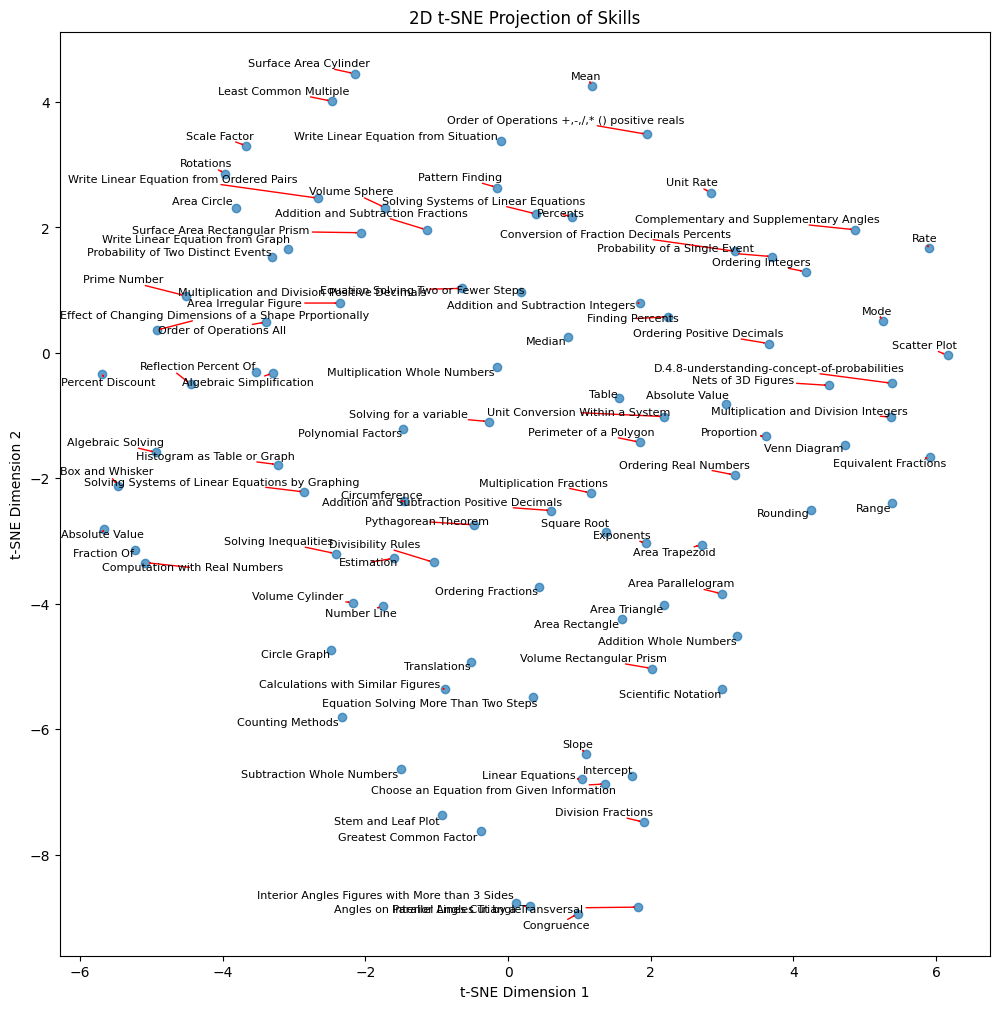

In [6]:
# Perform t-SNE to get to 2D
tsne = TSNE(n_components=2, random_state=42)
df_embeddings[['tsne_1', 'tsne_2']] = tsne.fit_transform(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']])

plt.figure(figsize=(12, 12))
plt.scatter(df_embeddings['tsne_1'], df_embeddings['tsne_2'], alpha=0.7)

texts = []
for i, row in df_embeddings.iterrows():
        texts.append(plt.text(row['tsne_1'], row['tsne_2'], row['skill_name'], fontsize=8, ha='right', va='bottom'))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Projection of Skills')

plt.show()


# 4) Clustering

## 4.1) Hierarchical Clustering

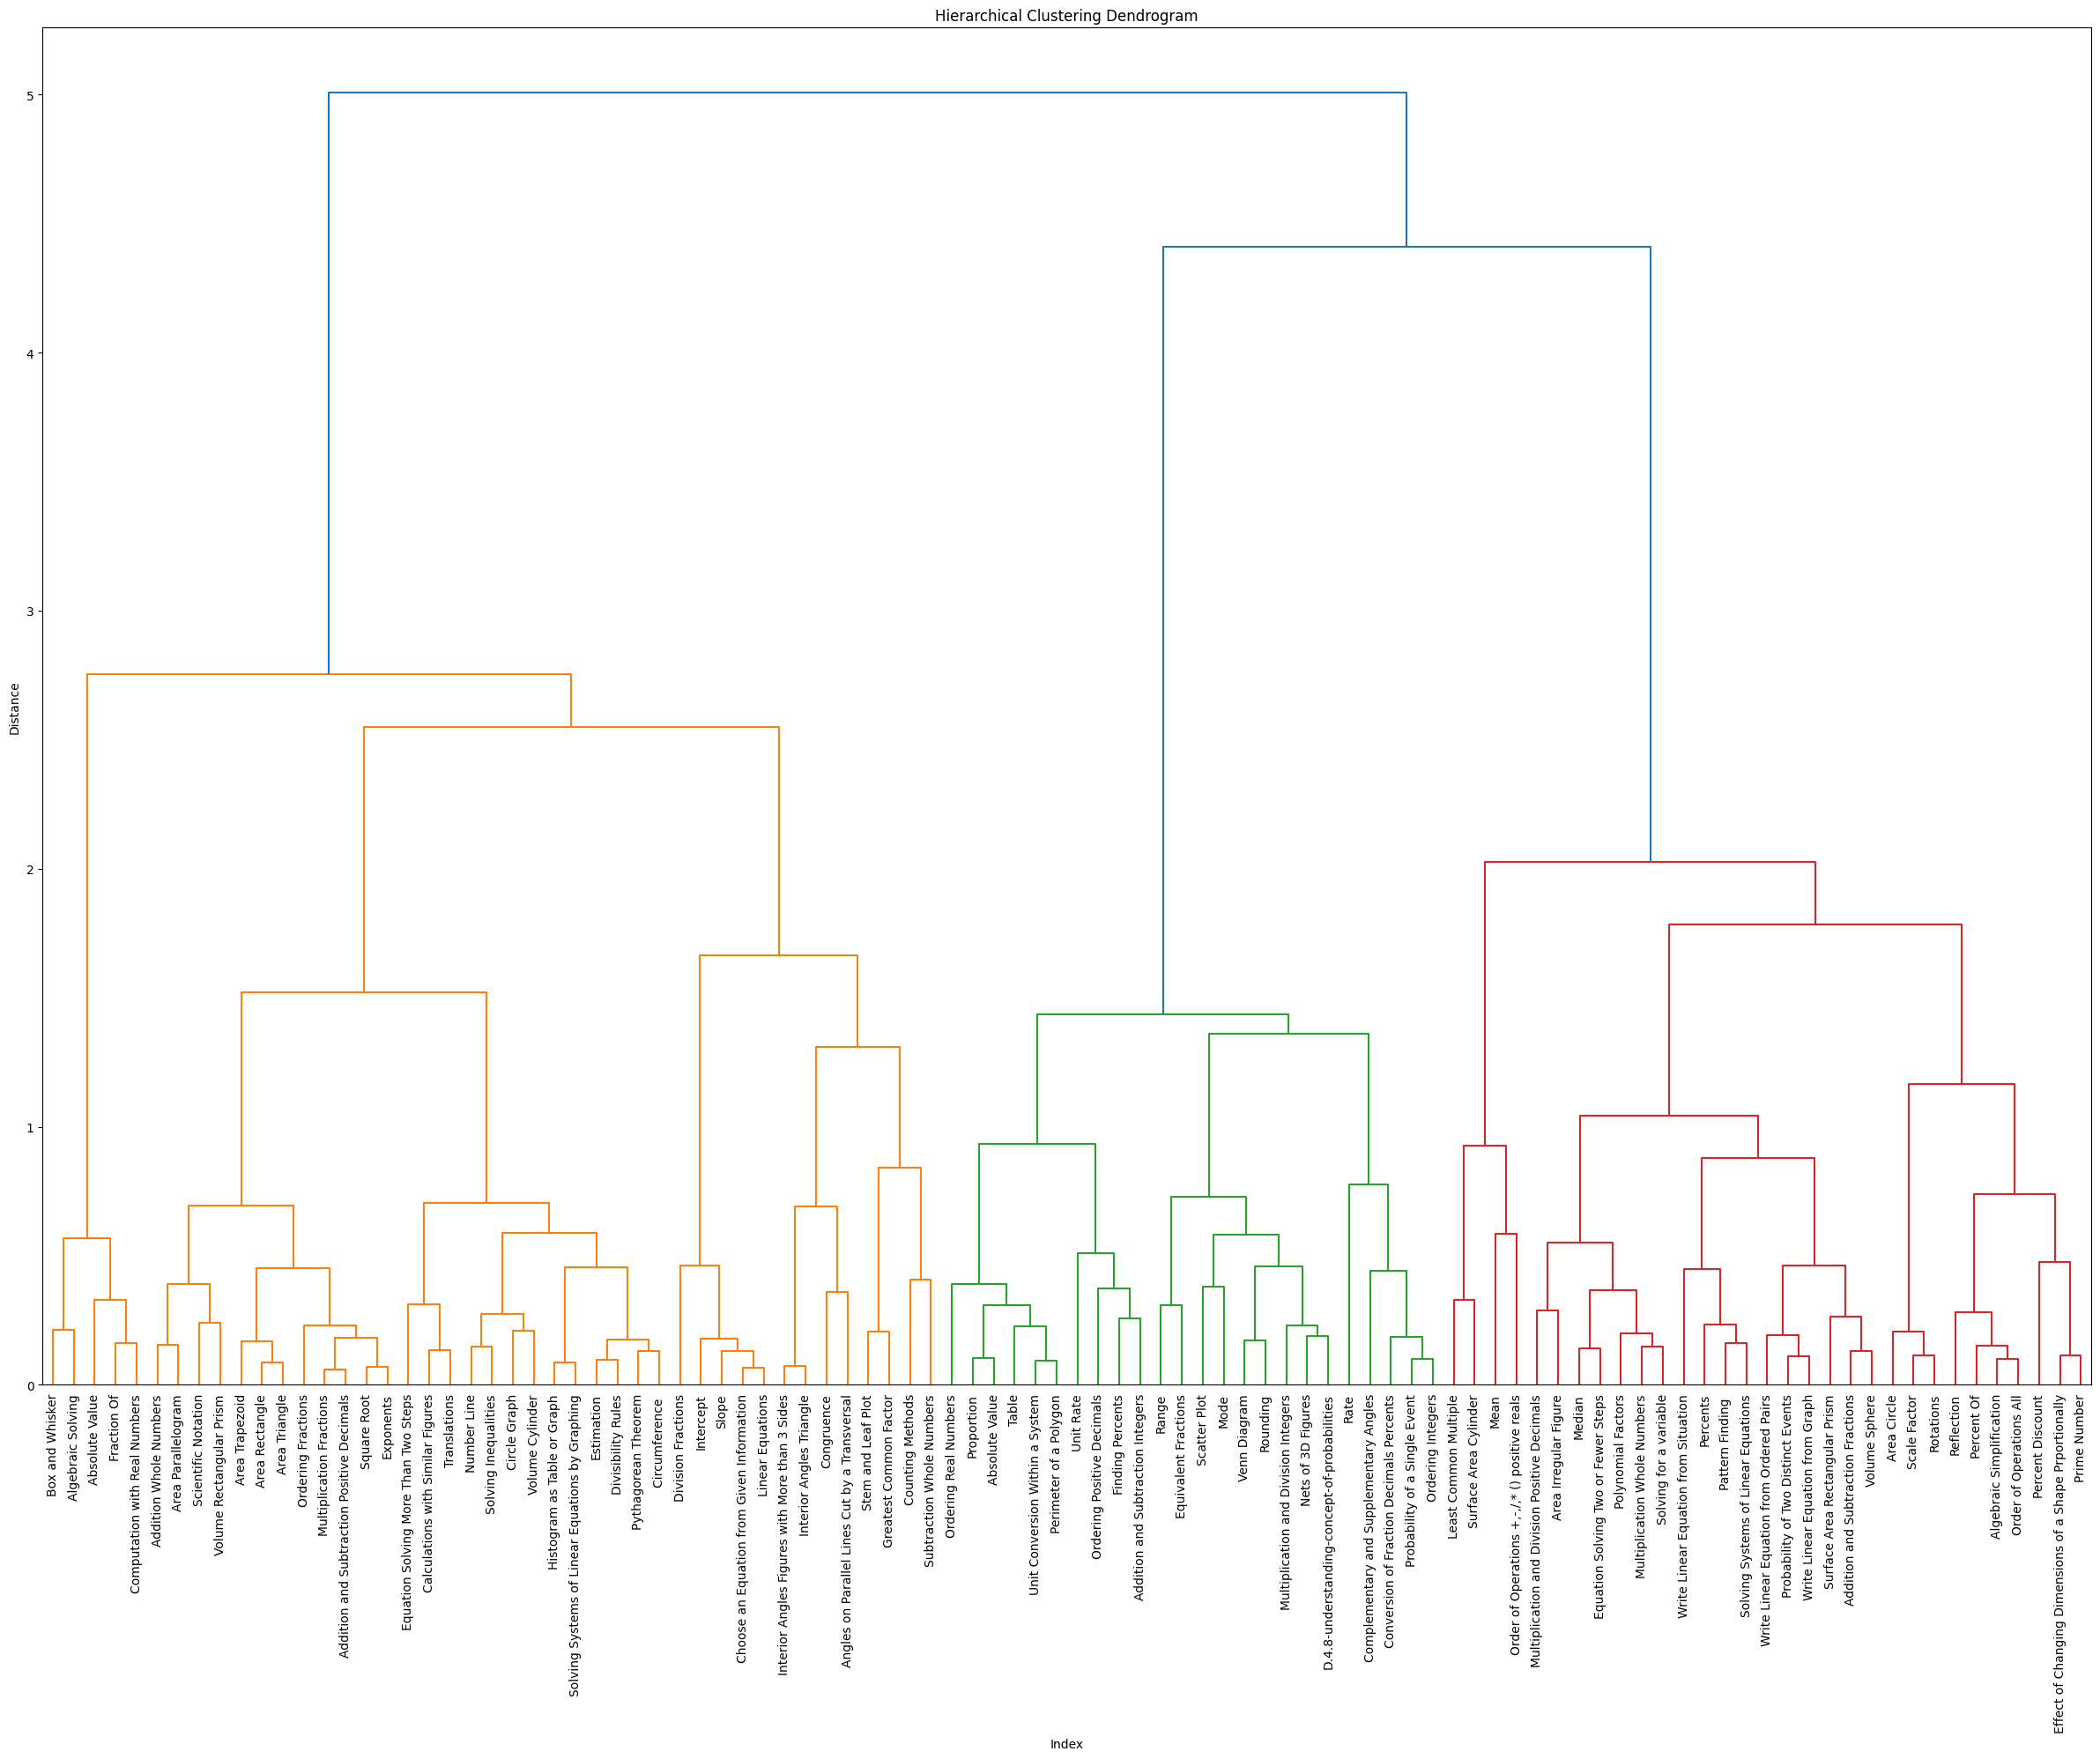

In [7]:
# Calculate the hierarchical matrix
linkage_matrix = sch.linkage(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']], method='ward')

plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()


## 4.2) K-Means Clustering

### 4.2.1) Elbow-method


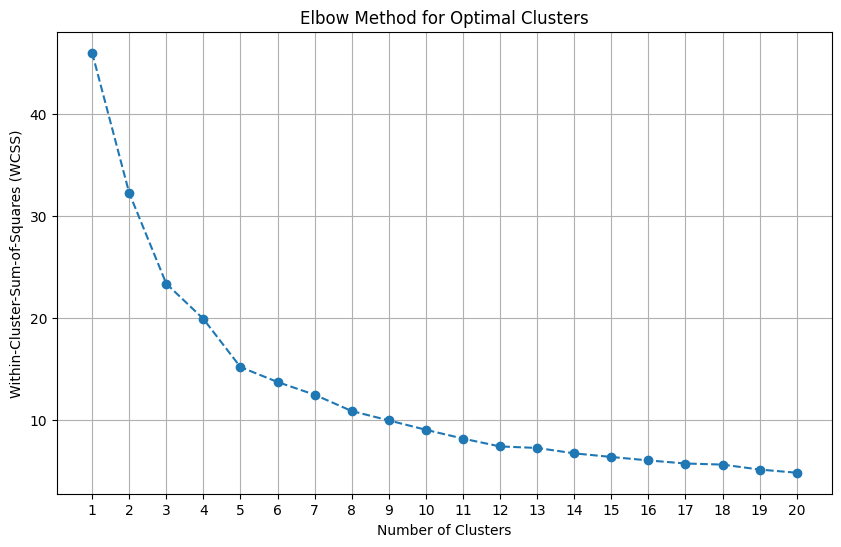

In [8]:
# Data preparation
data = df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']]

wcss_list = []
range_n_clusters = range(1, 21)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data)
    wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, wcss_list, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster-Sum-of-Squares (WCSS)')
plt.xticks(range_n_clusters)
plt.grid()
plt.show()


The number of clusters should be 5.

In [9]:
n_clusters = 5

# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_embeddings['cluster'] = kmeans.fit_predict(data)

for cluster in range(n_clusters):
    print(f"Cluster {cluster+1}:")
    skills = df_embeddings[df_embeddings['cluster'] == cluster]['skill_name'].tolist()
    print(", ".join(skills))
    print("-" * 400)



Cluster 1:
Stem and Leaf Plot, Interior Angles Figures with More than 3 Sides, Interior Angles Triangle, Congruence, Angles on Parallel Lines Cut by a Transversal, Division Fractions, Subtraction Whole Numbers, Scientific Notation, Choose an Equation from Given Information, Intercept, Linear Equations, Slope, Greatest Common Factor
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cluster 2:
Box and Whisker, Histogram as Table or Graph, Effect of Changing Dimensions of a Shape Prportionally, Fraction Of, Percent Of, Prime Number, Absolute Value, Algebraic Simplification, Algebraic Solving, Percent Discount, Reflection, Order of Operations Al